In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import mlflow
import mlflow.sklearn
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score,
                             ConfusionMatrixDisplay)

In [2]:
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

In [4]:
# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('../data/cs-training.csv', index_col=0)
print(df.shape)
df.head()

(150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
# ── Clean ─────────────────────────────────────────────────────────────────────
df = df.dropna(subset=['SeriousDlqin2yrs'])

# Fill missing values with median (safest for financial data)
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)

# Remove outliers (age = 0 is a data error)
df = df[df['age'] > 18]
df = df[df['age'] < 100]
df = df[df['RevolvingUtilizationOfUnsecuredLines'] <= 1]

print(f"Clean shape: {df.shape}")
print(f"Default rate: {df['SeriousDlqin2yrs'].mean():.2%}")

Clean shape: (146665, 11)
Default rate: 5.99%


In [6]:
# ── Features ──────────────────────────────────────────────────────────────────
FEATURES = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents'
]
TARGET = 'SeriousDlqin2yrs'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (117332, 10) | Test: (29333, 10)


In [7]:
# ── Train with MLflow tracking ─────────────────────────────────────────────────
mlflow.set_experiment("credit-risk-scoring")

with mlflow.start_run(run_name="xgboost_baseline"):

    model = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=10,   # handles class imbalance
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    print(f"\nROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred))

    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 5)
    mlflow.log_metric("roc_auc", auc)
    mlflow.sklearn.log_model(model, "xgboost_model")

# Save model locally too
joblib.dump(model, '../src/model/credit_model.pkl')
print("Model saved.")

2026/03/15 01:33:41 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/15 01:33:41 INFO mlflow.store.db.utils: Updating database tables
2026/03/15 01:33:42 INFO mlflow.tracking.fluent: Experiment with name 'credit-risk-scoring' does not exist. Creating a new experiment.
2026/03/15 01:33:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 01:33:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



ROC-AUC: 0.8632
              precision    recall  f1-score   support

           0       0.97      0.87      0.92     27575
           1       0.24      0.65      0.35      1758

    accuracy                           0.86     29333
   macro avg       0.61      0.76      0.64     29333
weighted avg       0.93      0.86      0.89     29333

Model saved.


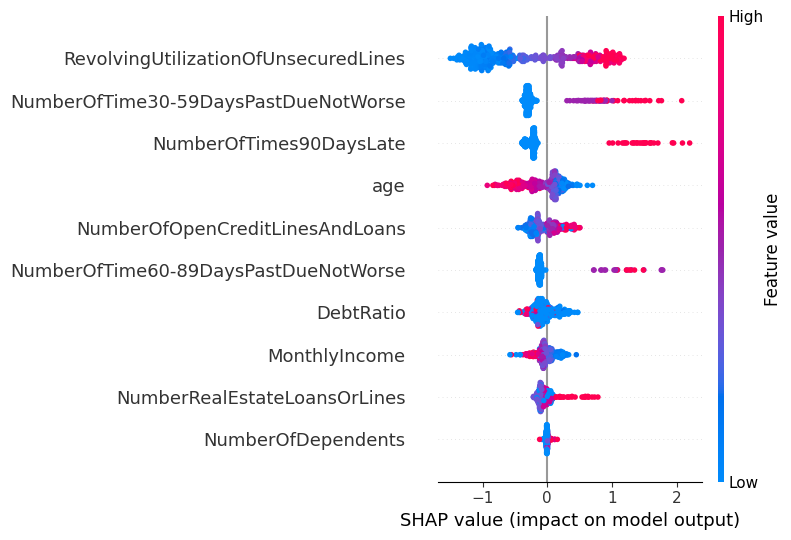

SHAP summary saved.


In [8]:
# ── SHAP Explainability ────────────────────────────────────────────────────────
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:500])

plt.figure()
shap.summary_plot(shap_values, X_test[:500], feature_names=FEATURES, show=False)
plt.tight_layout()
plt.savefig('../data/shap_summary.png', dpi=150)
plt.show()
print("SHAP summary saved.")

In [9]:
# ── Single prediction + explanation ───────────────────────────────────────────
def explain_prediction(applicant: dict) -> dict:
    """
    Takes applicant feature dict, returns risk score + top factors.
    """
    input_df = pd.DataFrame([applicant])
    proba = model.predict_proba(input_df)[0][1]
    sv = explainer.shap_values(input_df)[0]

    factors = sorted(
        zip(FEATURES, sv),
        key=lambda x: abs(x[1]),
        reverse=True
    )

    return {
        "default_probability": round(float(proba), 4),
        "risk_label": "HIGH RISK" if proba > 0.5 else "LOW RISK",
        "top_factors": [
            {"feature": f, "impact": round(float(v), 4)}
            for f, v in factors[:5]
        ]
    }

# Test it
sample = X_test.iloc[0].to_dict()
result = explain_prediction(sample)
print(result)

{'default_probability': 0.2196, 'risk_label': 'LOW RISK', 'top_factors': [{'feature': 'RevolvingUtilizationOfUnsecuredLines', 'impact': -1.0203}, {'feature': 'NumberOfTime30-59DaysPastDueNotWorse', 'impact': 0.817}, {'feature': 'NumberOfTimes90DaysLate', 'impact': -0.2651}, {'feature': 'DebtRatio', 'impact': -0.1568}, {'feature': 'NumberOfTime60-89DaysPastDueNotWorse', 'impact': -0.1376}]}
